## Extracción de Caracteristicas

Esta seccion aborda las caracteristicas a extraer para entrenar un modelo de clasificación

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, lfilter, filtfilt
from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis, entropy
import pywt
from typing import List, Tuple, Dict, Any
import os
import glob
import nolds
from joblib import Parallel, delayed
import algoritmos_deteccion as ad

c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\nolds\datasets.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [7]:
# ==============================================================================
# 1. Dominio del Tiempo
# ==============================================================================
def caracteristicas_tiempo(segmento: np.ndarray, rms_nominal: float) -> dict:
    """Extrae las características seleccionadas del dominio del tiempo."""
    
    rms_segmento_val = np.sqrt(np.mean(segmento**2))
    profundidad_relativa_val = rms_segmento_val / rms_nominal if rms_nominal > 1e-6 else 0.0
    pico_abs = np.max(np.abs(segmento))
    factor_cresta_val = pico_abs / rms_segmento_val if rms_segmento_val > 1e-6 else 0.0
    curtosis_val = kurtosis(segmento)
    
    return {
        'rms_segmento': rms_segmento_val,
        'profundidad_relativa': profundidad_relativa_val,
        'factor_cresta': factor_cresta_val,
        'curtosis': curtosis_val,
    }

# ==============================================================================
# 2. Dominio de la Frecuencia 
# ==============================================================================
def caracteristicas_frecuencia(segmento: np.ndarray) -> dict:
    """Extrae únicamente la energía espectral (FFT)."""
    n = len(segmento)
    if n < 2: return {'fft_energia': 0}

    fft_vals = np.fft.fft(segmento)[:n // 2]
    psd = np.abs(fft_vals)**2 / n
    energia_espectral = np.sum(psd)
    
    return {
        'fft_energia': energia_espectral,
    }

# ==============================================================================
# 3. Dominio Wavelet y Envolvente 
# ==============================================================================
def caracteristicas_wavelet(segmento: np.ndarray, wavelet: str = 'db4', max_level: int = 4) -> dict:
    """Extrae energía, entropía y desviación estándar de los coeficientes wavelet."""
    coeffs = pywt.wavedec(segmento, wavelet, level=max_level)
    caracteristicas = {}
    
    for i in range(1, len(coeffs)):
        nivel_coeffs = coeffs[-i]
        nivel = i
        
        caracteristicas[f'wavelet_energia_cD{nivel}'] = np.sum(nivel_coeffs**2)
        
        energia = caracteristicas[f'wavelet_energia_cD{nivel}']
        p = (nivel_coeffs**2) / energia if energia > 1e-6 else 0
        caracteristicas[f'wavelet_entropia_cD{nivel}'] = -np.sum(p * np.log2(p + 1e-12))
        
        caracteristicas[f'wavelet_std_cD{nivel}'] = np.std(nivel_coeffs)
        
    return caracteristicas

def caracteristicas_envolvente(senal: np.ndarray) -> dict:
    """Calcula la media y desviación estándar de la envolvente de Hilbert."""
    envolvente = np.abs(hilbert(senal))
    return {
        'env_media': np.mean(envolvente),
        'env_std': np.std(envolvente)
    }

# ==============================================================================
# 4. FUNCIÓN MAESTRA 
# ==============================================================================
def extraer_caracteristicas(segmento_evento: np.ndarray, fs: int, rms_nominal_val: float) -> dict:
    """
    Orquesta la extracción del conjunto final de características "Top 1".
    """
    caracteristicas = {}
    
    # Llama a las versiones ajustadas y a las que no necesitaron cambios
    caracteristicas.update(caracteristicas_tiempo(segmento_evento, rms_nominal_val))
    caracteristicas.update(caracteristicas_frecuencia(segmento_evento))
    caracteristicas.update(caracteristicas_wavelet(segmento_evento))
    caracteristicas.update(caracteristicas_envolvente(segmento_evento))
    
    # La lista final de características que se quiere mantener
    caracteristicas_top_1_requeridas = [
        'curtosis', 'env_media', 'env_std', 'factor_cresta', 'fft_energia', 
        'profundidad_relativa', 'rms_segmento', 'wavelet_energia_cD1', 
        'wavelet_energia_cD2', 'wavelet_energia_cD3', 'wavelet_energia_cD4', 
        'wavelet_entropia_cD1', 'wavelet_entropia_cD2', 'wavelet_entropia_cD3', 
        'wavelet_entropia_cD4', 'wavelet_std_cD1','wavelet_std_cD2','wavelet_std_cD3','wavelet_std_cD4'
    ]
    
    # Filtrar el diccionario para devolver solo las claves requeridas
    caracteristicas_filtradas = {clave: valor for clave, valor in caracteristicas.items() if clave in caracteristicas_top_1_requeridas}
    
    return caracteristicas_filtradas

In [ ]:
def procesar_un_archivo(etiqueta, ruta_archivo, fs):
    """Procesa un único archivo de señales y devuelve sus características y duraciones."""
    print(f"-> Iniciando procesamiento para: '{etiqueta}'")
    try:
        df_senales = pd.read_csv(ruta_archivo, index_col=0)
    except FileNotFoundError:
        return (None, []) # Devuelve una tupla vacía si el archivo no existe
    
    lista_features = []
    lista_duraciones = []
    for nombre_columna in df_senales.columns:
        # (Lógica de detección, consolidación y extracción idéntica a la anterior)
        senal_completa = df_senales[nombre_columna].values
        eventos_detectados = ad.detectar_eventos_con_fusion(senal_completa, fs)
        eventos_consolidados = []
        if len(eventos_detectados) > 1:
            inicio_consolidado, fin_consolidado = eventos_detectados[0][0], eventos_detectados[-1][1]
            eventos_consolidados.append((inicio_consolidado, fin_consolidado))
        elif len(eventos_detectados) == 1:
            eventos_consolidados = eventos_detectados
        
        if not eventos_consolidados: continue
        
        rms_nom_completa = ad.rms_nominal(senal_completa, fs)
        for inicio, fin in eventos_consolidados:
            segmento_evento = senal_completa[inicio:fin]
            if len(segmento_evento) == 0: continue
            
            caracteristicas = extraer_caracteristicas(segmento_evento, fs, rms_nom_completa)
            duracion = fin - inicio
            caracteristicas['etiqueta'] = etiqueta
            caracteristicas['columna_origen'] = nombre_columna
            caracteristicas['duracion_muestras'] = duracion
            lista_features.append(caracteristicas)
            lista_duraciones.append(duracion)

    if not lista_features: return (None, [])
    
    print(f"-> Finalizado: '{etiqueta}'")
    return (pd.DataFrame(lista_features), lista_duraciones)

def generar_features_normales(ruta_archivo_normal, duraciones_reales, fs, num_muestras):
    """Genera las características para la clase Normal."""
    print("\n--- Procesando la clase 'Normal' ---")
    try:
        df_normales = pd.read_csv(ruta_archivo_normal, index_col=0)
    except FileNotFoundError:
        print(f"  -> ERROR: No se encontró el archivo de señales normales.")
        return None
        
    senales_normales_pool = [df_normales[col].values for col in df_normales.columns]
    lista_features_normales = []

    for _ in range(num_muestras):
        duracion_aleatoria = np.random.choice(duraciones_reales)
        idx_senal = np.random.randint(0, len(senales_normales_pool))
        senal_completa = senales_normales_pool[idx_senal]

        if len(senal_completa) > duracion_aleatoria:
            inicio = np.random.randint(0, len(senal_completa) - duracion_aleatoria)
            segmento = senal_completa[inicio : inicio + duracion_aleatoria]
            rms_nom = ad.rms_nominal(senal_completa, fs)
            caracteristicas = extraer_caracteristicas(segmento, fs, rms_nom)
            caracteristicas['etiqueta'] = 'Normal'
            caracteristicas['columna_origen'] = f'normal_from_pool_{idx_senal}'
            caracteristicas['duracion_muestras'] = duracion_aleatoria
            lista_features_normales.append(caracteristicas)

    if not lista_features_normales: return None
    
    return pd.DataFrame(lista_features_normales)


# ==============================================================================
# SECCIÓN DE CONFIGURACIÓN Y ORQUESTACIÓN
# ==============================================================================
if __name__ == '__main__':
    
    FS = 7200
    NUM_MUESTRAS_NORMALES = 4100
    DIRECTORIO_SALIDA = 'Dataset_Final_Generado'
    DIRECTORIO_TEMP = os.path.join(DIRECTORIO_SALIDA, 'temp')
    NOMBRE_ARCHIVO_CONSOLIDADO = 'Dataset_Caracteristicas_Final.csv'

    ARCHIVOS_A_PROCESAR = {
        'Sag': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv',
        'Sag_Armonico': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Armonic\Clase_2_Armonico.csv',
        'Sag_Multiple': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Multiple\Clase_3_sagmultiple.csv',
        'Sag_Notch': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Notch\Clase_4_sagnotch.csv',
        'Sag_Transitorios': r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Transitorios\Clase_5_Transitorios.csv'
    }
    RUTA_ARCHIVO_NORMAL = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Normal\Clase_0_normal.csv'

    # --- LÓGICA PRINCIPAL OPTIMIZADA ---
    os.makedirs(DIRECTORIO_TEMP, exist_ok=True)
    
    # --- LÓGICA PRINCIPAL PARALELIZADA ---
    print("--- FASE 1: Procesando archivos de eventos en paralelo ---")
    
    # n_jobs=-1 usa todos los núcleos disponibles de tu CPU
    resultados_paralelos = Parallel(n_jobs=-1)(
        delayed(procesar_un_archivo)(etiqueta, ruta, FS) for etiqueta, ruta in ARCHIVOS_A_PROCESAR.items()
    )

    # Desempaquetar los resultados
    lista_dfs_eventos = [res[0] for res in resultados_paralelos if res[0] is not None]
    todas_las_duraciones = [duracion for res in resultados_paralelos for duracion in res[1]]
    
    print(f"\nSe procesaron {len(lista_dfs_eventos)} clases de eventos.")

    # FASE 2: Procesar clase normal (esto es rápido, no necesita paralelismo)
    if todas_las_duraciones:
        df_normal = generar_features_normales(RUTA_ARCHIVO_NORMAL, todas_las_duraciones, FS, NUM_MUESTRAS_NORMALES)
        if df_normal is not None:
            lista_dfs_eventos.append(df_normal)

    # FASE 3: Consolidar todos los resultados
    print("\n--- FASE 3: Consolidando todos los resultados ---")
    if not lista_dfs_eventos:
        print("No se generaron características para consolidar.")
    else:
        df_final = pd.concat(lista_dfs_eventos, ignore_index=True).fillna(0)
        
        columnas_info = ['etiqueta', 'columna_origen', 'duracion_muestras']
        columnas_features = sorted([col for col in df_final.columns if col not in columnas_info])
        df_final = df_final[columnas_info + columnas_features]

        os.makedirs(DIRECTORIO_SALIDA, exist_ok=True)
        ruta_salida_completa = os.path.join(DIRECTORIO_SALIDA, NOMBRE_ARCHIVO_CONSOLIDADO)
        df_final.to_csv(ruta_salida_completa, index=False)
        
        print(f"\n¡ÉXITO! Se guardó el dataset final en '{ruta_salida_completa}'")
        print("Conteo de eventos por clase en el dataset final:")
        print(df_final['etiqueta'].value_counts())

## t-SNE

Calculando la proyección t-SNE... (esto puede tardar unos minutos)


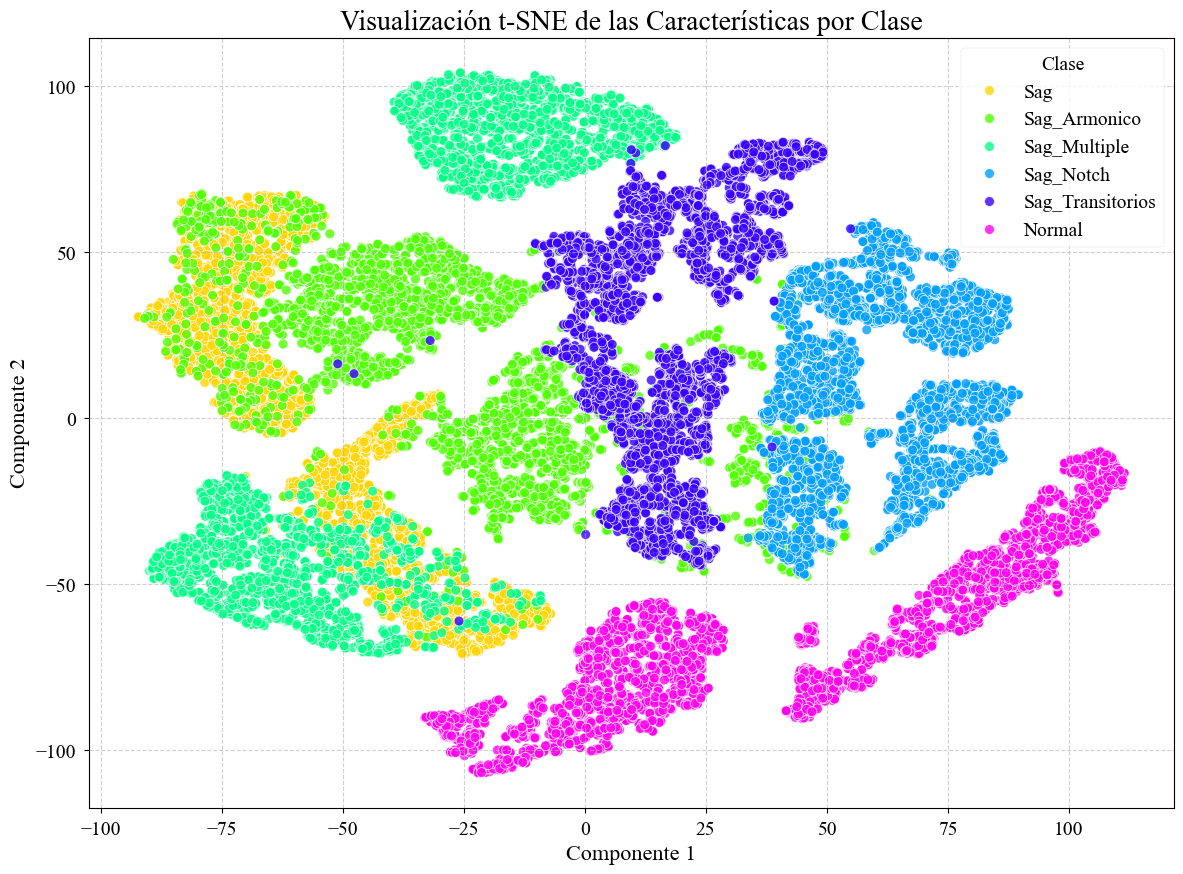

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def _setup_academic_style():
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif', 'font.serif': ['Times New Roman'],
        'mathtext.fontset': 'stix', 'font.size': 14,
        'axes.labelsize': 16, 'axes.titlesize': 18,
        'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'figure.figsize': (10, 6),
        'lines.linewidth': 2
    })

# Preparamos los datos
data_path = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Final_Generado\Dataset_Caracteristicas_Final.csv'
df = pd.read_csv(data_path)
X = df.drop(columns=['etiqueta', 'columna_origen', 'duracion_muestras'])
y = df['etiqueta']

# Es importante escalar los datos antes de t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Calculando la proyección t-SNE... (esto puede tardar unos minutos)")

# --- CORRECCIÓN AQUÍ ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Crear un DataFrame para la visualización
tsne_df = pd.DataFrame(data=X_tsne, columns=['Componente 1', 'Componente 2'])
tsne_df['etiqueta'] = y

# Graficar
_setup_academic_style()
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x="Componente 1", y="Componente 2",
    hue="etiqueta",
    palette=sns.color_palette("hsv", len(df['etiqueta'].unique())),
    data=tsne_df,
    legend="full",
    alpha=0.8,
    s=50
)
plt.title('Visualización t-SNE de las Características por Clase', fontsize=20)
plt.xlabel('Componente 1', fontsize=16)
plt.ylabel('Componente 2', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Clase')
# plt.savefig("tsne_visualization.svg", format='svg', dpi=300) # Descomenta si quieres guardar el archivo
plt.show()